Projet 2025–2026 — Mini‑BERT en PyTorch (AG News → MLM, puis IMDB → Classification)

Souheb Omar Osman



Objectif :

Dans ce projet, je reproduis un pipeline de type BERT minimal en PyTorch :

    Pré‑entraînement auto‑supervisé par Masked Language Modeling (MLM) sur AG News (15% de tokens masqués).
    Fine‑tuning supervisé sur IMDB (classification binaire) en utilisant le vecteur [CLS].
    Ablation : comparaison pré‑entraîné vs from scratch (mêmes hyperparamètres de fine‑tuning).

Le but est de montrer l’intérêt du pré‑training (ou ses limites) quand on dispose de peu de données étiquetées.

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="The PyTorch API of nested tensors is in prototype stage"
)


warnings.filterwarnings("ignore", message="The secret `HF_TOKEN` does not exist")


In [1]:

!pip -q install torch torchvision torchaudio
!pip -q install datasets transformers matplotlib

In [3]:
import math
import random
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import BertTokenizer  # autorisé ici uniquement pour la tokenisation

# =========================
# Reproductibilité (seed)
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Device utilisé:", device)

Torch: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
Device utilisé: cuda


## I) Données & tokenisation (AG News)
On charge **AG News**, on conserve une fraction (10% demandé), puis on tokenize avec **BertTokenizer** en séquences de **256 tokens**.

In [4]:
# Hyperparamètres de données
MAX_LEN = 256
BATCH_SIZE = 32

# Fractions (10% demandé ; si CPU trop lent, mettre 0.01)
AG_TRAIN_FRAC = 0.10
AG_TEST_FRAC  = 0.10

ag = load_dataset("ag_news")

ag_train = ag["train"].shuffle(seed=SEED).select(range(int(AG_TRAIN_FRAC * len(ag["train"]))))
ag_test  = ag["test"].shuffle(seed=SEED).select(range(int(AG_TEST_FRAC  * len(ag["test"]))))

print("AG train:", len(ag_train), "| AG test:", len(ag_test))
print("Exemple:", ag_train[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the latest cached version of the dataset since ag_news couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /root/.cache/huggingface/datasets/ag_news/default/0.0.0/eb185aade064a813bc0b7f42de02595523103ca4 (last modified on Thu Jan  1 20:14:12 2026).


AG train: 12000 | AG test: 760
Exemple: {'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [5]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_ag(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

ag_train_tok = ag_train.map(tokenize_ag, batched=True, remove_columns=["text"])
ag_test_tok  = ag_test.map(tokenize_ag,  batched=True, remove_columns=["text"])

print("CLS token:", tokenizer.cls_token, "id:", tokenizer.cls_token_id)
print("Premier token (doit être CLS id):", ag_train_tok[0]["input_ids"][0])

CLS token: [CLS] id: 101
Premier token (doit être CLS id): 101


### Collate MLM (15% de tokens masqués)
Le MLM calcule la loss uniquement sur les positions masquées :
- `labels = -100` sur les positions non masquées (ignorées par la loss),
- `labels = token_original` sur les positions masquées,
- `input_ids` : les positions masquées sont remplacées par `[MASK]`.

On évite de masquer `[CLS]`, `[SEP]`, `[PAD]`.


In [6]:
mask_id = tokenizer.mask_token_id
pad_id  = tokenizer.pad_token_id
cls_id  = tokenizer.cls_token_id
sep_id  = tokenizer.sep_token_id

SPECIAL_IDS = {cls_id, sep_id, pad_id}

def mlm_collate_fn(batch, mlm_prob=0.15):
    input_ids = torch.tensor([x["input_ids"] for x in batch], dtype=torch.long)
    attention_mask = torch.tensor([x["attention_mask"] for x in batch], dtype=torch.long)

    labels = torch.full_like(input_ids, fill_value=-100)

    can_mask = torch.ones_like(input_ids, dtype=torch.bool)
    for sid in SPECIAL_IDS:
        can_mask &= (input_ids != sid)

    rand = torch.rand(input_ids.shape)
    mask_pos = (rand < mlm_prob) & can_mask

    labels[mask_pos] = input_ids[mask_pos]
    input_ids_masked = input_ids.clone()
    input_ids_masked[mask_pos] = mask_id

    return {"input_ids": input_ids_masked,
            "attention_mask": attention_mask,
            "labels": labels}

In [7]:
train_mlm_loader = DataLoader(
    ag_train_tok,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=mlm_collate_fn
)

test_mlm_loader = DataLoader(
    ag_test_tok,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=mlm_collate_fn
)

batch = next(iter(train_mlm_loader))
print("Shapes:", batch["input_ids"].shape, batch["attention_mask"].shape, batch["labels"].shape)

Shapes: torch.Size([32, 256]) torch.Size([32, 256]) torch.Size([32, 256])


## II) Architecture — Mini‑BERT + tête MLM
Mini‑BERT : token embedding + positional embedding + TransformerEncoder (`d_model=128`, `nhead=4`, `num_layers=4` par défaut).

In [8]:
class MiniBERT(nn.Module):
    def __init__(self, vocab_size, max_len=256, d_model=128, nhead=4, num_layers=4,
                 dim_ff=512, dropout=0.1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

    def forward(self, input_ids, attention_mask):
        B, L = input_ids.shape
        pos = torch.arange(L, device=input_ids.device).unsqueeze(0).expand(B, L)

        x = self.tok_emb(input_ids) + self.pos_emb(pos)
        x = self.ln(x)
        x = self.drop(x)

        key_padding_mask = (attention_mask == 0)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        return x  # (B, L, d_model)

class BERTPretrainMLM(nn.Module):
    def __init__(self, vocab_size, max_len=256, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.bert = MiniBERT(vocab_size, max_len=max_len, d_model=d_model, nhead=nhead, num_layers=num_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, attention_mask):
        h = self.bert(input_ids, attention_mask)
        logits = self.lm_head(h)
        return logits

In [9]:
vocab_size = tokenizer.vocab_size
model_mlm = BERTPretrainMLM(vocab_size, max_len=MAX_LEN, d_model=128, nhead=4, num_layers=4).to(device)

n_params = sum(p.numel() for p in model_mlm.parameters())
print(f"Paramètres: {n_params/1e6:.2f} M")

Paramètres: 8.67 M


## III) Pré‑entraînement MLM (AG News)
Optimiseur **AdamW**, perte **CrossEntropy(ignore_index=-100)**, entraînement sur **10 époques** + courbes train/val.


In [10]:
from torch.optim import AdamW

criterion_mlm = nn.CrossEntropyLoss(ignore_index=-100)
optimizer_mlm = AdamW(model_mlm.parameters(), lr=2e-4)

def train_one_epoch_mlm(model, loader):
    model.train()
    total_loss, n_steps = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer_mlm.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion_mlm(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss.backward()
        optimizer_mlm.step()

        total_loss += loss.item()
        n_steps += 1
    return total_loss / max(1, n_steps)

@torch.no_grad()
def eval_mlm(model, loader):
    model.eval()
    total_loss, n_steps = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion_mlm(logits.view(-1, logits.size(-1)), labels.view(-1))
        total_loss += loss.item()
        n_steps += 1
    return total_loss / max(1, n_steps)

In [11]:
EPOCHS_MLM = 10

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS_MLM + 1):
    tr = train_one_epoch_mlm(model_mlm, train_mlm_loader)
    va = eval_mlm(model_mlm, test_mlm_loader)
    train_losses.append(tr)
    val_losses.append(va)
    print(f"Epoch {epoch:02d} | train loss={tr:.4f} | val loss={va:.4f}")

Epoch 01 | train loss=7.9863 | val loss=7.4605
Epoch 02 | train loss=7.3661 | val loss=7.3386
Epoch 03 | train loss=7.2520 | val loss=7.1997
Epoch 04 | train loss=7.1601 | val loss=7.1686
Epoch 05 | train loss=7.0833 | val loss=7.0787
Epoch 06 | train loss=7.0223 | val loss=7.0335
Epoch 07 | train loss=6.9483 | val loss=6.9301
Epoch 08 | train loss=6.9185 | val loss=6.9519
Epoch 09 | train loss=6.8389 | val loss=6.9155
Epoch 10 | train loss=6.7895 | val loss=6.8349


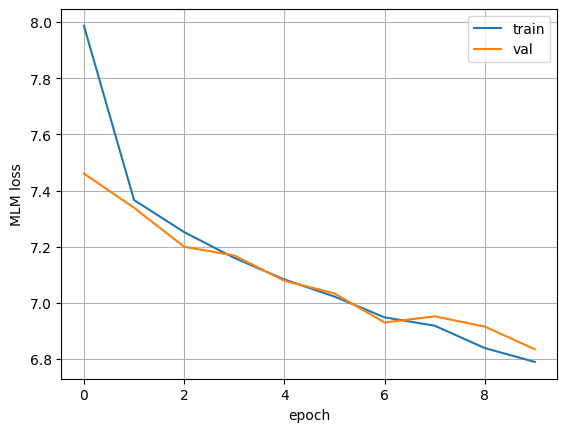

In [12]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MLM loss")
plt.legend()
plt.grid(True)
plt.show()

### Test qualitatif `[MASK]` (Top‑5)
On encode la phrase, on récupère les logits sur la position `[MASK]`, puis on affiche les 5 tokens les plus probables.


In [14]:
@torch.no_grad()
def topk_mask_predictions(model, text, k=5):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=MAX_LEN)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    mask_positions = (input_ids[0] == mask_id).nonzero(as_tuple=False).flatten()
    if len(mask_positions) == 0:
        print("Pas de [MASK] dans la phrase.")
        return []

    pos = int(mask_positions[0].item())
    logits = model(input_ids, attention_mask)
    scores = logits[0, pos]

    topk = torch.topk(scores, k=k)
    ids = topk.indices.tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    return list(zip(toks, [float(v) for v in topk.values.cpu()]))

print(topk_mask_predictions(model_mlm, "The cat sat on the [MASK].", k=5))

[('.', 7.018779754638672), ('in', 5.010503768920898), ('to', 4.646172046661377), ('the', 4.545553684234619), ("'", 4.4271745681762695)]


## IV) Fine‑tuning IMDB (classification binaire)
On conserve **1%** du train IMDB.  
Classifieur : représentation **[CLS]** (position 0) → couche linéaire vers 2 classes.


In [15]:
IMDB_TRAIN_FRAC = 0.01   # 1% demandé
IMDB_TEST_FRAC  = 0.10

imdb = load_dataset("imdb")
imdb_train = imdb["train"].shuffle(seed=SEED).select(range(int(IMDB_TRAIN_FRAC * len(imdb["train"]))))
imdb_test  = imdb["test"].shuffle(seed=SEED).select(range(int(IMDB_TEST_FRAC  * len(imdb["test"]))))

print("IMDB train:", len(imdb_train), "| IMDB test:", len(imdb_test))
print("Exemple:", {"label": imdb_train[0]["label"], "text_snippet": imdb_train[0]["text"][:200] + "..."})

IMDB train: 250 | IMDB test: 2500
Exemple: {'label': 1, 'text_snippet': 'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...'}


In [16]:
def tokenize_imdb(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

imdb_train_tok = imdb_train.map(tokenize_imdb, batched=True, remove_columns=["text"])
imdb_test_tok  = imdb_test.map(tokenize_imdb,  batched=True, remove_columns=["text"])

def cls_collate_fn(batch):
    input_ids = torch.tensor([x["input_ids"] for x in batch], dtype=torch.long)
    attention_mask = torch.tensor([x["attention_mask"] for x in batch], dtype=torch.long)
    labels = torch.tensor([x["label"] for x in batch], dtype=torch.long)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

train_cls_loader = DataLoader(imdb_train_tok, batch_size=32, shuffle=True, collate_fn=cls_collate_fn)
test_cls_loader  = DataLoader(imdb_test_tok,  batch_size=32, shuffle=False, collate_fn=cls_collate_fn)

In [17]:
class BERTClassifier(nn.Module):
    def __init__(self, vocab_size, max_len=256, d_model=128, nhead=4, num_layers=4, num_classes=2):
        super().__init__()
        self.encoder = MiniBERT(vocab_size, max_len=max_len, d_model=d_model, nhead=nhead, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask):
        h = self.encoder(input_ids, attention_mask)
        cls_vec = h[:, 0, :]              # [CLS]
        logits = self.classifier(cls_vec) # (B, 2)
        return logits

In [18]:
criterion_cls = nn.CrossEntropyLoss()

def train_one_epoch_cls(model, loader, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion_cls(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(1, len(loader)), total_correct / max(1, total)

@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion_cls(logits, labels)

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(1, len(loader)), total_correct / max(1, total)

### Expérience A — Fine‑tuning avec pré‑training MLM
On copie les poids de l’encodeur appris en MLM (`model_mlm.bert`) dans le classifieur, puis on fine‑tune sur IMDB.


In [19]:
model_pretrained = BERTClassifier(vocab_size, max_len=MAX_LEN, d_model=128, nhead=4, num_layers=4).to(device)
model_pretrained.encoder.load_state_dict(model_mlm.bert.state_dict())

optimizer_pretrained = AdamW(model_pretrained.parameters(), lr=2e-4)

EPOCHS_FT = 5
pt_train_loss, pt_train_acc = [], []
pt_test_loss, pt_test_acc = [], []

for epoch in range(1, EPOCHS_FT + 1):
    tr_l, tr_a = train_one_epoch_cls(model_pretrained, train_cls_loader, optimizer_pretrained)
    te_l, te_a = eval_cls(model_pretrained, test_cls_loader)

    pt_train_loss.append(tr_l); pt_train_acc.append(tr_a)
    pt_test_loss.append(te_l);  pt_test_acc.append(te_a)

    print(f"[Pretrained] Epoch {epoch:02d} | train loss={tr_l:.4f} acc={tr_a:.3f} | test loss={te_l:.4f} acc={te_a:.3f}")

[Pretrained] Epoch 01 | train loss=0.7394 acc=0.448 | test loss=0.6991 acc=0.506
[Pretrained] Epoch 02 | train loss=0.6769 acc=0.576 | test loss=0.7024 acc=0.513
[Pretrained] Epoch 03 | train loss=0.6851 acc=0.576 | test loss=0.7543 acc=0.516
[Pretrained] Epoch 04 | train loss=0.6559 acc=0.600 | test loss=0.7232 acc=0.508
[Pretrained] Epoch 05 | train loss=0.6265 acc=0.636 | test loss=0.7962 acc=0.524


### Expérience B — Ablation : entraînement from scratch
Même protocole, mêmes hyperparamètres, mais initialisation aléatoire (pas de pré‑training).


In [20]:
model_scratch = BERTClassifier(vocab_size, max_len=MAX_LEN, d_model=128, nhead=4, num_layers=4).to(device)
optimizer_scratch = AdamW(model_scratch.parameters(), lr=2e-4)

sc_train_loss, sc_train_acc = [], []
sc_test_loss, sc_test_acc = [], []

for epoch in range(1, EPOCHS_FT + 1):
    tr_l, tr_a = train_one_epoch_cls(model_scratch, train_cls_loader, optimizer_scratch)
    te_l, te_a = eval_cls(model_scratch, test_cls_loader)

    sc_train_loss.append(tr_l); sc_train_acc.append(tr_a)
    sc_test_loss.append(te_l);  sc_test_acc.append(te_a)

    print(f"[Scratch]    Epoch {epoch:02d} | train loss={tr_l:.4f} acc={tr_a:.3f} | test loss={te_l:.4f} acc={te_a:.3f}")

[Scratch]    Epoch 01 | train loss=0.7929 acc=0.440 | test loss=0.7249 acc=0.503
[Scratch]    Epoch 02 | train loss=0.7150 acc=0.532 | test loss=0.7342 acc=0.497
[Scratch]    Epoch 03 | train loss=0.7031 acc=0.536 | test loss=0.7043 acc=0.503
[Scratch]    Epoch 04 | train loss=0.6839 acc=0.544 | test loss=0.7012 acc=0.500
[Scratch]    Epoch 05 | train loss=0.6819 acc=0.560 | test loss=0.6880 acc=0.539


## V) Courbes et comparaison
On trace les losses et les accuracies test pour comparer **pré‑entraîné vs scratch**.


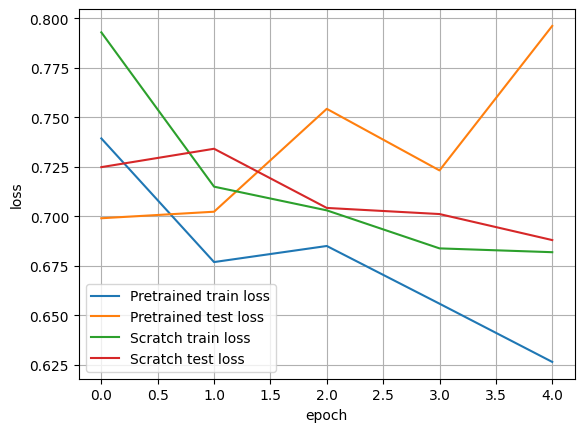

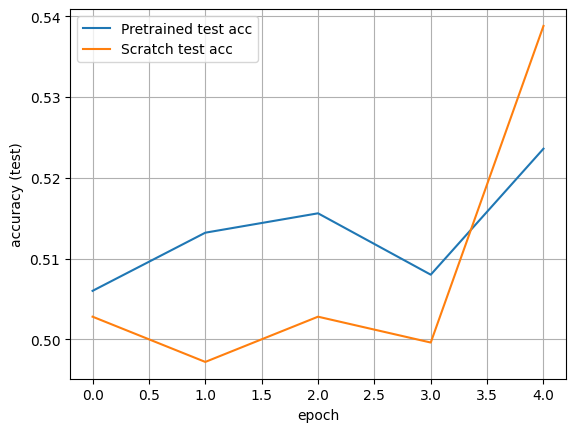

In [21]:
plt.figure()
plt.plot(pt_train_loss, label="Pretrained train loss")
plt.plot(pt_test_loss, label="Pretrained test loss")
plt.plot(sc_train_loss, label="Scratch train loss")
plt.plot(sc_test_loss, label="Scratch test loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(pt_test_acc, label="Pretrained test acc")
plt.plot(sc_test_acc, label="Scratch test acc")
plt.xlabel("epoch"); plt.ylabel("accuracy (test)")
plt.legend(); plt.grid(True); plt.show()

Conclusion ::

MLM sur AG News : la loss train et val diminue globalement au fil des 10 époques, ce qui confirme que le Mini-BERT apprend à reconstruire des tokens masqués à partir du contexte.

Test [MASK] : sur “The cat sat on the [MASK].”, les Top-5 prédictions contiennent surtout des tokens très fréquents (ponctuation / mots outils). Cela suggère que le pré-training, bien qu’effectif (loss ↓), reste modéré et/ou que cette phrase est hors domaine par rapport à AG News.

Fine-tuning IMDB (1%) : avec seulement 250 exemples d’entraînement, les performances restent proches du hasard (≈ 0.50–0.54) et varient d’une époque à l’autre. On observe une baisse de la loss train, mais la loss test peut stagner/augmenter, signe d’un surapprentissage rapide sur un petit échantillon.

Ablation (pré-entraîné vs scratch) : dans cette exécution, le modèle from scratch atteint une accuracy test légèrement supérieure en fin d’entraînement (≈ 0.54) par rapport au modèle pré-entraîné (≈ 0.52). Cela indique que le pré-training MLM n’apporte pas ici un gain net, probablement parce que (i) le pré-training est encore limité (10 époques, 10% AG News) et (ii) le fine-tuning est réalisé sur très peu de données, ce qui rend la comparaison sensible à la variance.